<a href="https://colab.research.google.com/github/bawamehar/pytorch-practice/blob/main/simple_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# Create a Model Class that inherits nn.Module
class Model(nn.Module):
  # input layer (4 features of the flower) --> Hidden Layer (number of neurons --> H2 --> Output
  def __init__(self, in_features=4, h1=8, h2=8, out_features = 3):
    super().__init__() #instantiate nn.model
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [3]:
#pick a manual seed for randomiztion
torch.manual_seed(41)
# Create an instance of model
model = Model()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [6]:
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [7]:
#change last column from string to integer
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)

/tmp/ipykernel_25585/2064359643.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


In [8]:
#Train Test Split! Set X, y
X = my_df.drop('variety', axis = 1)
y = my_df['variety']

In [9]:
# Convert these to numpy array
X = X.values
y = y.values

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [12]:
# Covert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [13]:
#Convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [14]:
# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()
#Choose Adam Optimizer, lr = learning rate(if error doesnt go down after a bunch of iteration(epochs), lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [15]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)>

In [16]:
#Train our model!
#Epochs? (1 run thru all the training data)
epoch = 100
losses = []
for i in range(epoch):
  #go forward and get a prediction
  y_pred = model.forward(X_train) #get predicted results

  #measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted value vs the y_train

  #keep track of the losses
  losses.append(loss.detach().numpy())

  #print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do back propagation: take error rate of fw prop. and feed it back thru the network
  # to fine tune the weights

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 and loss: 1.1318365335464478
Epoch: 10 and loss: 0.9658561944961548
Epoch: 20 and loss: 0.6789938807487488
Epoch: 30 and loss: 0.40048947930336
Epoch: 40 and loss: 0.22509503364562988
Epoch: 50 and loss: 0.12207334488630295
Epoch: 60 and loss: 0.07481689751148224
Epoch: 70 and loss: 0.054512787610292435
Epoch: 80 and loss: 0.044374898076057434
Epoch: 90 and loss: 0.03837943449616432


Text(0.5, 0, 'Epoch')

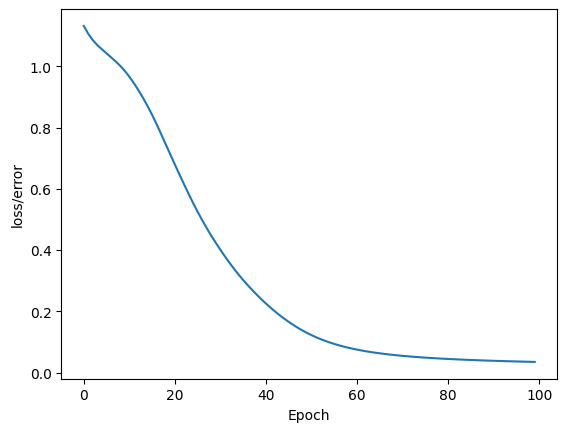

In [17]:
plt.plot(range(epoch), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

In [18]:
#Evalute model on test data set
with torch.no_grad(): # bascially turn off back propagation
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test) #find loss or error

In [19]:
loss

tensor(0.1458)

In [20]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    #will tell what type of flower class network thinks it is
    print(f'{i+1}.) {str(y_val)} \t {y_test[i]}')

    #correct or not
    if y_val.argmax().item() == y_test[i]:
      correct +=1

print(f'We got {correct} correct!')

1.) tensor([-7.7212,  1.5826,  4.8685]) 	 2
2.) tensor([-10.2316,   0.5146,   8.7767]) 	 2
3.) tensor([-10.7282,   1.1893,   8.2408]) 	 2
4.) tensor([-4.4743,  3.5419, -1.1241]) 	 1
5.) tensor([-9.0954,  1.4687,  6.2899]) 	 2
6.) tensor([-2.2803,  3.7077, -4.1196]) 	 1
7.) tensor([-7.0740,  2.2070,  3.2966]) 	 2
8.) tensor([-4.2271,  3.6553, -1.5467]) 	 1
9.) tensor([-8.0707,  1.8280,  4.7897]) 	 2
10.) tensor([-10.8583,   0.5051,   9.3761]) 	 2
11.) tensor([-6.8676,  2.2165,  3.0859]) 	 2
12.) tensor([  9.4382,   3.2638, -18.8717]) 	 0
13.) tensor([  8.6037,   2.9307, -17.1502]) 	 0
14.) tensor([-1.0594,  3.1702, -4.7116]) 	 1
15.) tensor([  8.0310,   3.2450, -16.7844]) 	 0
16.) tensor([-6.7105,  2.4191,  2.6637]) 	 2
17.) tensor([  8.4678,   3.0888, -17.1317]) 	 0
18.) tensor([-7.6060,  1.7034,  4.5701]) 	 1
19.) tensor([  9.8628,   3.2141, -19.4757]) 	 0
20.) tensor([  7.7276,   2.8980, -15.7355]) 	 0
21.) tensor([-1.6920,  3.3948, -4.3016]) 	 1
22.) tensor([-10.0177,   1.0502,   7.

In [21]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [22]:
with torch.no_grad():
  print(model(new_iris))

tensor([  9.2092,   3.0850, -18.2915])


In [23]:
#Save NN Model
torch.save(model.state_dict(), 'my_first_pytorch_nn_model.pt')

In [24]:
# Load the saved model
new_model = Model()
new_model.load_state_dict(torch.load('my_first_pytorch_nn_model.pt'))

<All keys matched successfully>

In [25]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)